# Regularization: Teaching Your Model Some Self-Restraint

---

## The problem with trying too hard

Imagine you're studying for an exam by going through past papers. You could memorize every single answer and, if the exact same questions came up again, you'd score 100%. The dream of every student. But it won't happen. The real exam will have *similar* questions, not identical ones. What you actually need is to understand the *patterns* behind the answers, not to memorize blindly the answers themselves.

Models face exactly the same problem. A model with enough parameters can perfectly fit every point in the training set, but in doing so it ends up chasing noise, those random quirks of that particular dataset that won't appear in new data. This is overfitting, and we've seen it before.

So how do we tell a model: "learn the real patterns, but don't try *too* hard to fit every little bump"? One of the most effective answers is **regularization**. How? we add a cost for complexity to the loss function. The model now has to balance two things: fitting the data well *and* keeping itself simple.

$$\text{Total Loss} = \text{How wrong are my predictions?} + \lambda \times \text{How complex is my model?}$$

That $\lambda$ is a dial we control. Turn it up and the model is forced to stay simple (at the cost of fitting the training data less tightly). Turn it down and the model is free to get as complex as it wants.

What does "complexity" mean here, concretely? For instance, for linear models it comes down to **the size of the weights**. A model with huge weights is one that reacts wildly to small changes in input which is exactly the kind of twitchy, overfit behavior we want to avoid. Keeping the weights small keeps the model smooth and stable.

The two most common ways to penalize weight size are called **L2** and **L1** regularization, and they lead to surprisingly different behaviors. Let's see both in action.

In [48]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_regression, load_diabetes, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    LogisticRegression, RidgeCV, LassoCV
)
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Understanding the Problem: Overfitting

Let's first demonstrate the overfitting problem that regularization solves:

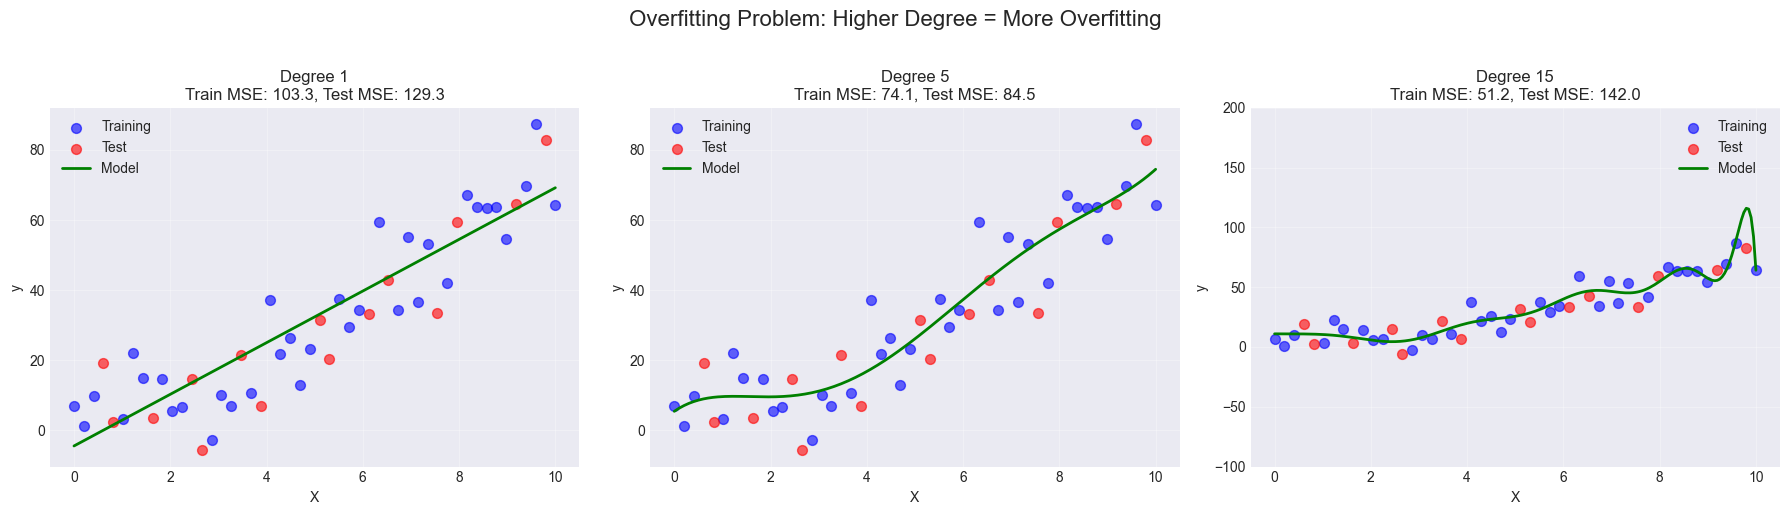

Observation: As polynomial degree increases, training error decreases
but test error increases (overfitting)!


In [49]:
# Generate polynomial data
np.random.seed(42)
X = np.linspace(0, 10, 50)
y = 2 + 3*X + 0.5*X**2 + np.random.normal(0, 10, 50)

X_train, X_test, y_train, y_test = train_test_split(
    X.reshape(-1, 1), y, test_size=0.3, random_state=42
)

# Fit high-degree polynomial without regularization
degrees = [1, 5, 15]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)

for idx, degree in enumerate(degrees):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_plot_poly = poly.transform(X_plot)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot_pred = model.predict(X_plot_poly)
    
    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    # Plot
    ax = axes[idx]
    ax.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training')
    ax.scatter(X_test, y_test, color='red', s=50, alpha=0.6, label='Test')
    ax.plot(X_plot, y_plot_pred, 'g-', linewidth=2, label='Model')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title(f'Degree {degree}\nTrain MSE: {train_mse:.1f}, Test MSE: {test_mse:.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    if degree == 15:
        ax.set_ylim(-100, 200)

plt.suptitle('Overfitting Problem: Higher Degree = More Overfitting', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Observation: As polynomial degree increases, training error decreases")
print("but test error increases (overfitting)!")

## 2. L2 Regularization (Ridge Regression)

Think about what happens when a polynomial model overfits. It creates those wild oscillations we saw above, swooping up and down to pass through every training point. To make those sharp turns, the model needs **very large coefficients**: big positive numbers followed by big negative numbers that nearly cancel each other out. That cancellation is fragile. A tiny shift in the data and the whole thing falls apart.

Ridge regression attacks this directly: it adds the **sum of squared weights** to the loss.

$$\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^{n} w_i^2$$

Now if the model wants to use a large weight, it has to "pay" for it. The optimizer will only keep a weight large if that weight genuinely helps reduce prediction error enough to justify the penalty. Weights that were large just to chase noise get shrunk down, because the noise-fitting benefit isn't worth the cost.

A few things to notice about Ridge:

- It **shrinks** all coefficients, but never kills them completely. Every feature keeps at least a tiny influence. This makes sense: squaring a small number gives a very small penalty, so there's little pressure to push a weight all the way to zero.
- When features are correlated, Ridge spreads the weight across them rather than arbitrarily picking one. This tends to make predictions more stable.
- The $\alpha$ parameter controls how aggressive the shrinking is. We'll figure out how to choose it later.

Let's see this in practice, here's what happens to that overfit polynomial as we increase $\alpha$:

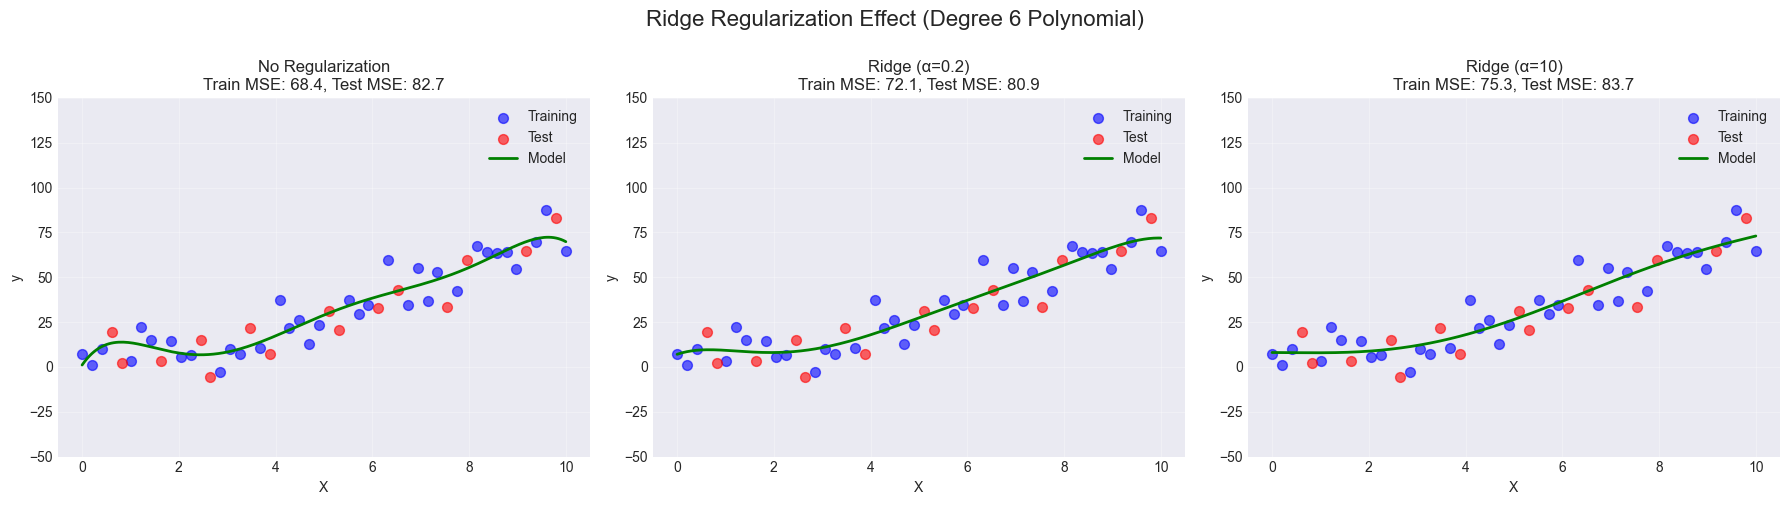


Key Observations:
- α = 0: Severe overfitting (wild oscillations)
- Small α: Slight improvement
- Moderate α: Good balance
- Large α: Underfitting (too smooth)


In [50]:
# Compare unregularized vs Ridge regression
degree = 6
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
X_plot_poly = poly.transform(X_plot)

# Different alpha values
alphas = [0, 0.2, 10]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, alpha in enumerate(alphas):
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)
    
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot_pred = model.predict(X_plot_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    ax = axes[idx]
    ax.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training')
    ax.scatter(X_test, y_test, color='red', s=50, alpha=0.6, label='Test')
    ax.plot(X_plot, y_plot_pred, 'g-', linewidth=2, label='Model')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    title = 'No Regularization' if alpha == 0 else f'Ridge (α={alpha})'
    ax.set_title(f'{title}\nTrain MSE: {train_mse:.1f}, Test MSE: {test_mse:.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-50, 150)

plt.suptitle(f'Ridge Regularization Effect (Degree {degree} Polynomial)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- α = 0: Severe overfitting (wild oscillations)")
print("- Small α: Slight improvement")
print("- Moderate α: Good balance")
print("- Large α: Underfitting (too smooth)")

### Ridge: Effect on Coefficients

Let's see how Ridge shrinks the coefficients:

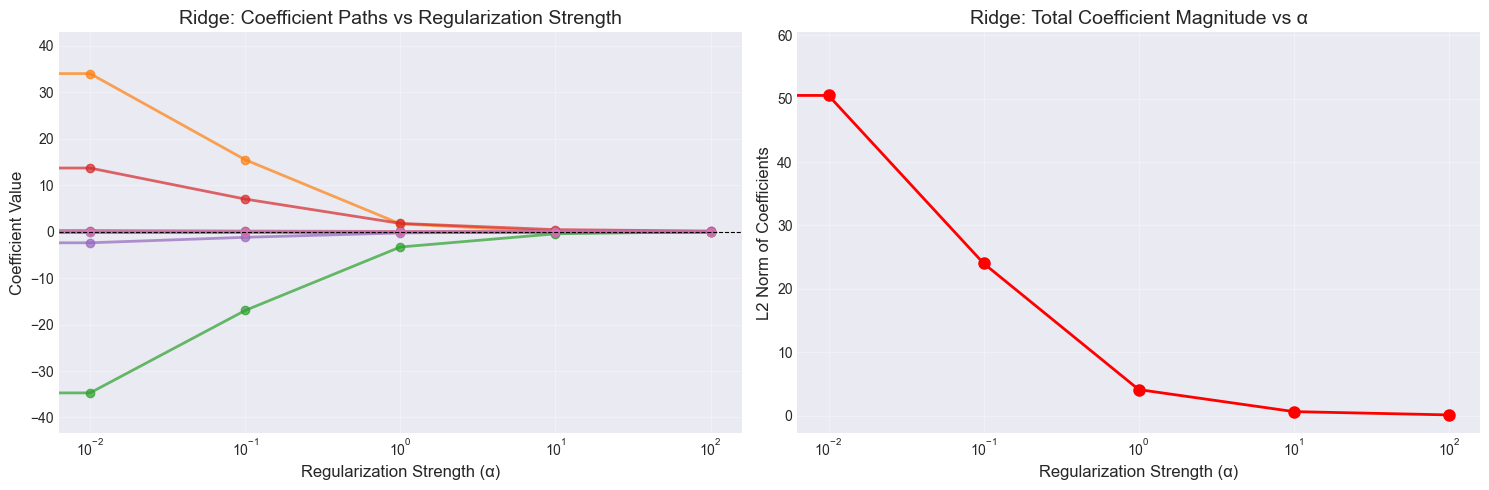


L2 Norms:
  α =   0.00: L2 norm = 57.60
  α =   0.01: L2 norm = 50.52
  α =   0.10: L2 norm = 24.02
  α =   1.00: L2 norm = 4.11
  α =  10.00: L2 norm = 0.64
  α = 100.00: L2 norm = 0.12

As α increases, coefficient magnitudes shrink!


In [51]:
# Compare coefficients for different alpha values
alphas_test = [0, 0.01, 0.1, 1, 10, 100]
coefficients = []

for alpha in alphas_test:
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    coefficients.append(model.coef_)

# Plot coefficient paths
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Coefficient values
for i in range(len(coefficients[0])):
    coef_path = [coefs[i] for coefs in coefficients]
    ax1.plot(alphas_test, coef_path, 'o-', alpha=0.7, linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Regularization Strength (α)', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('Ridge: Coefficient Paths vs Regularization Strength', fontsize=14)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(True, alpha=0.3)

# Plot 2: L2 norm of coefficients
l2_norms = [np.sqrt(np.sum(c**2)) for c in coefficients]
ax2.plot(alphas_test, l2_norms, 'o-', linewidth=2, markersize=8, color='red')
ax2.set_xscale('log')
ax2.set_xlabel('Regularization Strength (α)', fontsize=12)
ax2.set_ylabel('L2 Norm of Coefficients', fontsize=12)
ax2.set_title('Ridge: Total Coefficient Magnitude vs α', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nL2 Norms:")
for alpha, norm in zip(alphas_test, l2_norms):
    print(f"  α = {alpha:6.2f}: L2 norm = {norm:.2f}")
print("\nAs α increases, coefficient magnitudes shrink!")

## 3. L1 Regularization (Lasso Regression)

Ridge keeps all your features and just turns their volume down. But what if some features are genuinely useless? What if half the columns in your dataset are noise, and you'd be better off ignoring them entirely?

That's where Lasso comes in. Instead of penalizing squared weights, it penalizes **absolute values**:

$$\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^{n} |w_i|$$

This seemingly small change has a big consequence: Lasso doesn't just shrink weights, it **sets them exactly to zero**. It's doing feature selection for you, the model itself decides which features matter and which ones to throw away.

Why does the absolute value do this while the square doesn't? Here's the intuition: with L2, shrinking a weight from 0.1 to 0.0 saves you almost nothing (the penalty goes from 0.01 to 0). With L1, shrinking from 0.1 to 0.0 saves you a full 0.1 of penalty, this you did when you shrinked from 1.1 to 1.0 for instance. The reward for going all the way to zero is just as good as the reward for any other equal-sized reduction. So the optimizer happily kills off features whose contribution doesn't justify their cost. In financial terms, while the ROI for l2 of keep shrinking is marginal, for l1 its always the same. So it keeps doing that. 

The practical upside is, you get a **sparse model**: one that depends on only a handful of features. This makes the model easier to interpret and can actually improve generalization when many features are irrelevant.

The downside? Lasso can be a bit unstable with correlated features. If two features carry similar information, it tends to arbitrarily pick one and zero out the other, and the choice can flip depending on the random train/test split. We'll see how Elastic Net handles this shortly.

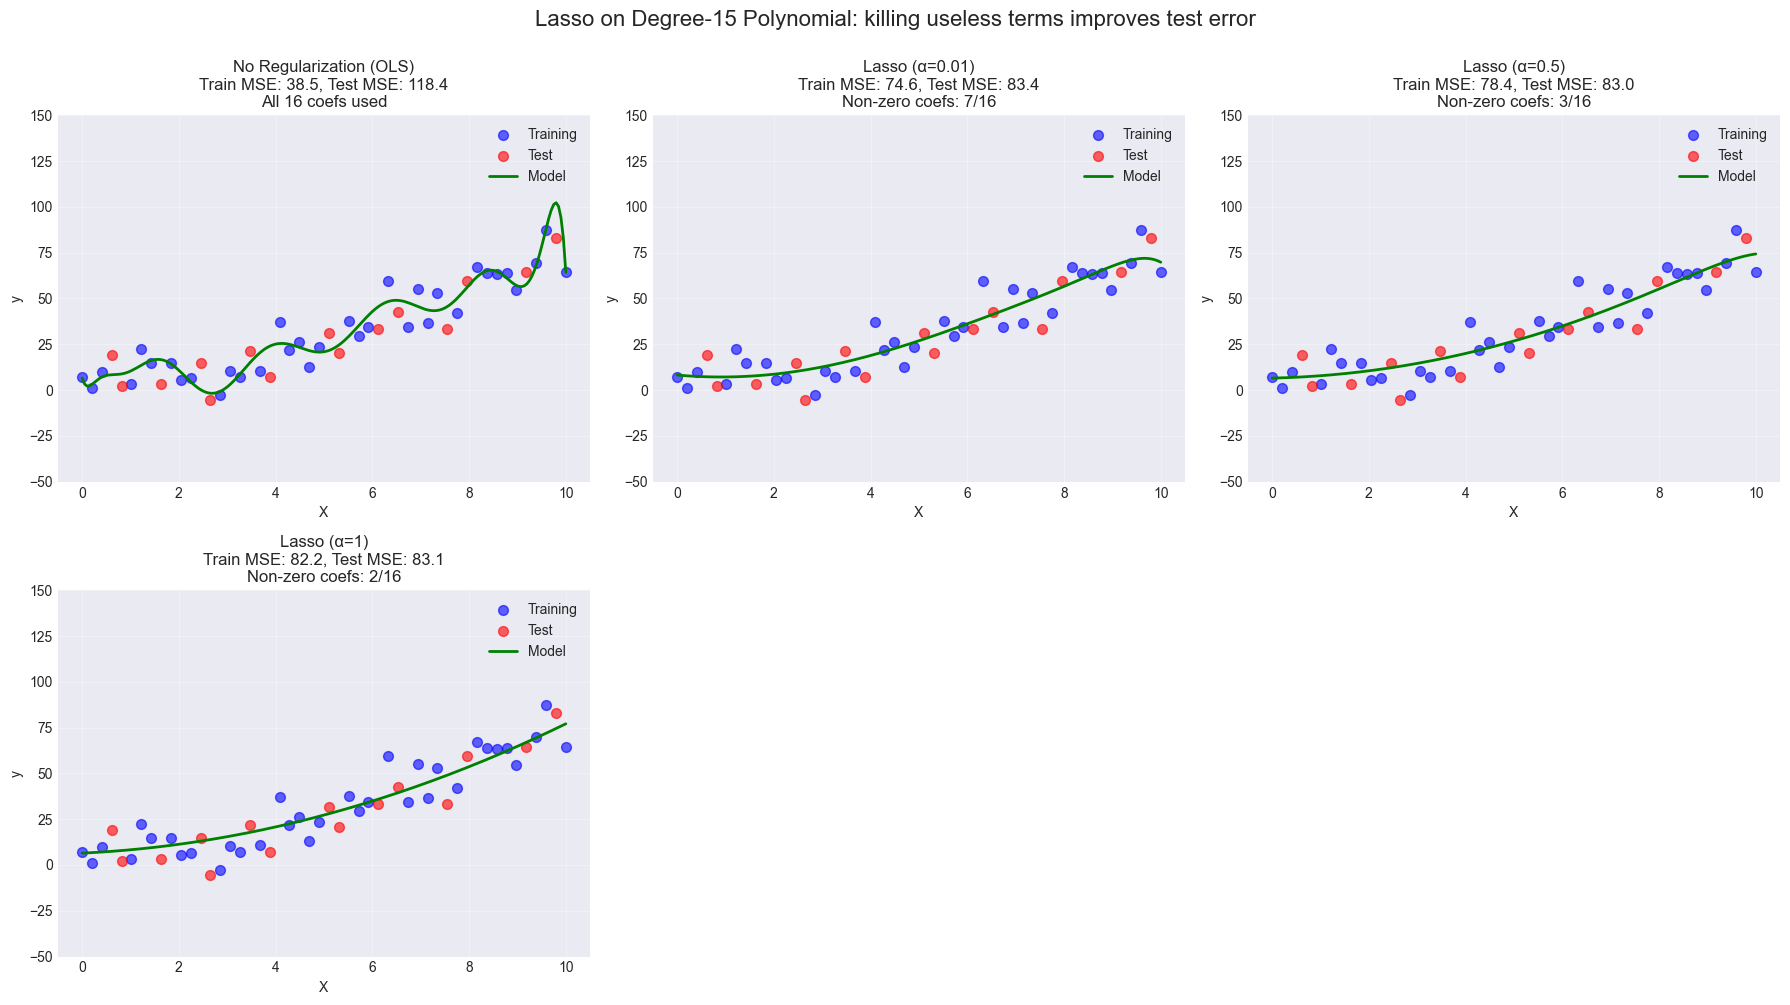

In [52]:
# With a degree-15 polynomial on quadratic data, most terms are pure noise.
# This is where Lasso shines: it can zero out the useless ones.
# Note: we scale the features first, that's because Lasso is very sensitive to feature scale.

degree_l = 15
poly_l = PolynomialFeatures(degree=degree_l)
X_train_poly_l = poly_l.fit_transform(X_train)
X_test_poly_l = poly_l.transform(X_test)
X_plot_poly_l = poly_l.transform(X_plot)

scaler_l = StandardScaler()
X_train_ls = scaler_l.fit_transform(X_train_poly_l)
X_test_ls = scaler_l.transform(X_test_poly_l)
X_plot_ls = scaler_l.transform(X_plot_poly_l)

alphas_lasso = [0, 0.01, 0.5, 1]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, alpha in enumerate(alphas_lasso):
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Lasso(alpha=alpha, max_iter=50000)
    
    model.fit(X_train_ls, y_train)
    
    y_train_pred = model.predict(X_train_ls)
    y_test_pred = model.predict(X_test_ls)
    y_plot_pred = model.predict(X_plot_ls)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    n_nonzero = np.sum(model.coef_ != 0)
    
    ax = axes[idx]
    ax.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training')
    ax.scatter(X_test, y_test, color='red', s=50, alpha=0.6, label='Test')
    ax.plot(X_plot, y_plot_pred, 'g-', linewidth=2, label='Model')
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    if alpha == 0:
        title = f'No Regularization (OLS)\nTrain MSE: {train_mse:.1f}, Test MSE: {test_mse:.1f}\nAll {len(model.coef_)} coefs used'
    else:
        title = f'Lasso (α={alpha})\nTrain MSE: {train_mse:.1f}, Test MSE: {test_mse:.1f}\nNon-zero coefs: {n_nonzero}/{len(model.coef_)}'
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-50, 150)

fig.delaxes(axes[5])
fig.delaxes(axes[4])

plt.suptitle(f'Lasso on Degree-{degree_l} Polynomial: killing useless terms improves test error',
             fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

### Lasso: Coefficient Sparsity

Lasso's key feature is that it drives coefficients to exactly zero:

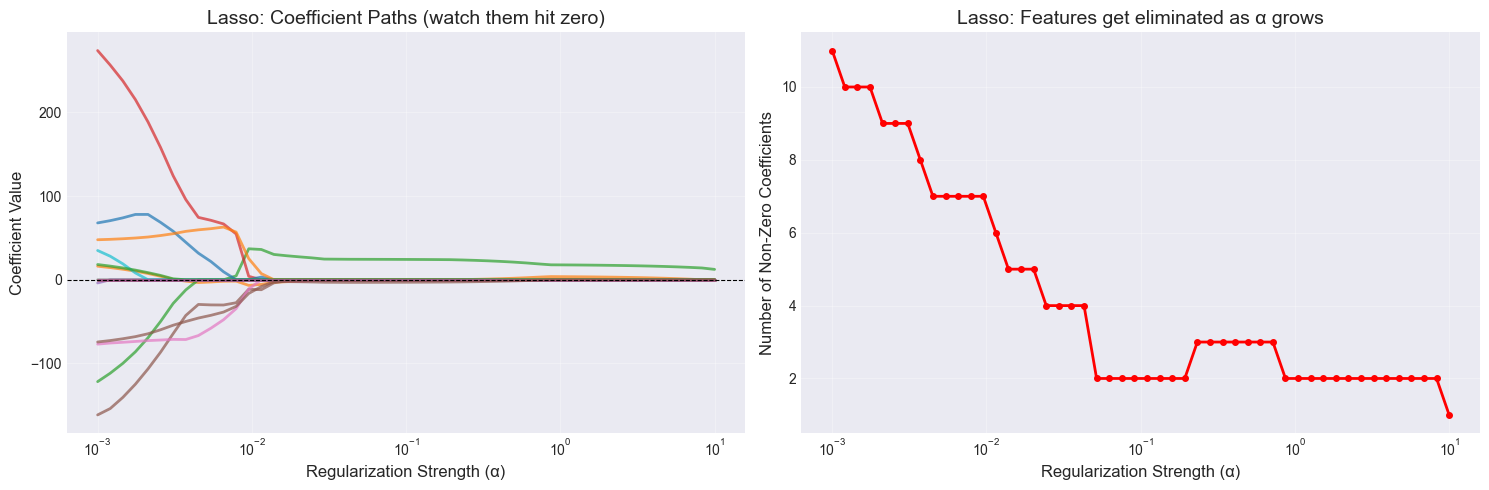


Lasso Sparsity:
  α =  0.01:  7/16 non-zero coefficients
  α =  0.10:  2/16 non-zero coefficients
  α =  0.50:  3/16 non-zero coefficients
  α =  1.00:  2/16 non-zero coefficients
  α =  5.00:  2/16 non-zero coefficients
  α = 10.00:  1/16 non-zero coefficients

Started with 16 polynomial terms, but only ~2-3 actually matter!


In [53]:
# Coefficient paths: how each weight evolves as alpha increases
alphas_lasso_test = np.logspace(-3, 1, 50)
lasso_coefficients = []
n_nonzero_list = []

for alpha in alphas_lasso_test:
    model = Lasso(alpha=alpha, max_iter=50000)
    model.fit(X_train_ls, y_train)
    lasso_coefficients.append(model.coef_)
    n_nonzero_list.append(np.sum(model.coef_ != 0))

lasso_coefficients = np.array(lasso_coefficients)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Coefficient paths
for i in range(lasso_coefficients.shape[1]):
    ax1.plot(alphas_lasso_test, lasso_coefficients[:, i], alpha=0.7, linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Regularization Strength (α)', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('Lasso: Coefficient Paths (watch them hit zero)', fontsize=14)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(True, alpha=0.3)

# Plot 2: Number of non-zero coefficients
ax2.plot(alphas_lasso_test, n_nonzero_list, 'o-', linewidth=2, markersize=4, color='red')
ax2.set_xscale('log')
ax2.set_xlabel('Regularization Strength (α)', fontsize=12)
ax2.set_ylabel('Number of Non-Zero Coefficients', fontsize=12)
ax2.set_title('Lasso: Features get eliminated as α grows', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLasso Sparsity:")
for alpha, n_nz in zip([0.01, 0.1, 0.5, 1, 5, 10], 
                        [np.sum(Lasso(alpha=a, max_iter=50000).fit(X_train_ls, y_train).coef_ != 0) 
                         for a in [0.01, 0.1, 0.5, 1, 5, 10]]):
    print(f"  α = {alpha:5.2f}: {n_nz:2d}/{lasso_coefficients.shape[1]} non-zero coefficients")
print(f"\nStarted with {lasso_coefficients.shape[1]} polynomial terms, but only ~2-3 actually matter!")

## 4. Elastic Net: Best of Both Worlds

**Elastic Net** combines L1 and L2 regularization:

$$\text{Loss} = \text{MSE} + \alpha \left( r \sum_{i=1}^{n} |w_i| + \frac{1-r}{2} \sum_{i=1}^{n} w_i^2 \right)$$

Where:
- $\alpha$ controls overall regularization strength
- $r$ (l1_ratio) balances L1 vs L2: r=1 is Lasso, r=0 is Ridge

### When to Use Elastic Net:
- When you have correlated features
- When you want some feature selection but not as aggressive as Lasso
- Often more stable than pure Lasso

## 6. Finding the Optimal Regularization Strength

The hyperparameter $\alpha$ controls regularization strength. How do we choose it?

### Method 1: Validation Curve

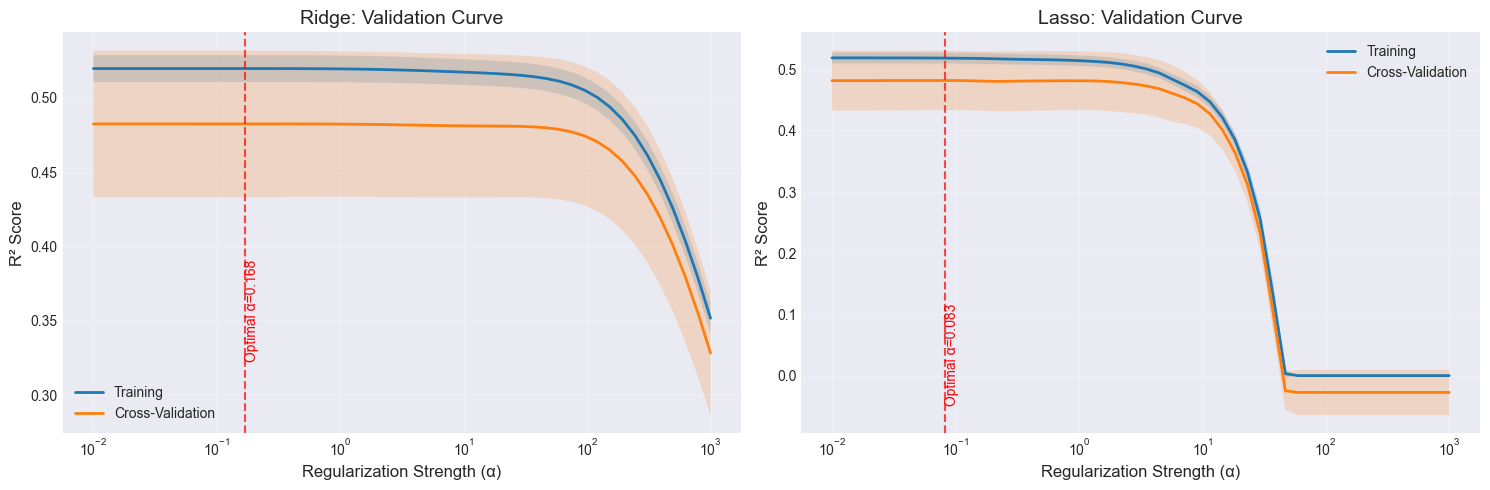


Optimal Alpha Values:
  Ridge: α = 0.1677
  Lasso: α = 0.0829


In [56]:
diabetes = load_diabetes()
X_d, y_d = diabetes.data, diabetes.target
scaler_d = StandardScaler()
X_ds = scaler_d.fit_transform(X_d)

# Test range of alpha values
alphas_range = np.logspace(-2, 3, 50)

# Ridge validation curve
train_scores_ridge, test_scores_ridge = validation_curve(
    Ridge(), X_ds, y_d,
    param_name='alpha',
    param_range=alphas_range,
    cv=5,
    scoring='r2'
)

# Lasso validation curve
train_scores_lasso, test_scores_lasso = validation_curve(
    Lasso(max_iter=50000), X_ds, y_d,
    param_name='alpha',
    param_range=alphas_range,
    cv=5,
    scoring='r2'
)

# Calculate means and stds
train_mean_ridge = train_scores_ridge.mean(axis=1)
train_std_ridge = train_scores_ridge.std(axis=1)
test_mean_ridge = test_scores_ridge.mean(axis=1)
test_std_ridge = test_scores_ridge.std(axis=1)

train_mean_lasso = train_scores_lasso.mean(axis=1)
train_std_lasso = train_scores_lasso.std(axis=1)
test_mean_lasso = test_scores_lasso.mean(axis=1)
test_std_lasso = test_scores_lasso.std(axis=1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Ridge
ax1.plot(alphas_range, train_mean_ridge, label='Training', linewidth=2)
ax1.fill_between(alphas_range, train_mean_ridge - train_std_ridge,
                train_mean_ridge + train_std_ridge, alpha=0.2)
ax1.plot(alphas_range, test_mean_ridge, label='Cross-Validation', linewidth=2)
ax1.fill_between(alphas_range, test_mean_ridge - test_std_ridge,
                test_mean_ridge + test_std_ridge, alpha=0.2)
ax1.set_xscale('log')
ax1.set_xlabel('Regularization Strength (α)', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Ridge: Validation Curve', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Mark optimal
best_alpha_ridge = alphas_range[np.argmax(test_mean_ridge)]
ax1.axvline(x=best_alpha_ridge, color='red', linestyle='--', alpha=0.7)
ax1.text(best_alpha_ridge, ax1.get_ylim()[0] + 0.05, 
        f'Optimal α={best_alpha_ridge:.3f}',
        rotation=90, fontsize=10, color='red')

# Lasso
ax2.plot(alphas_range, train_mean_lasso, label='Training', linewidth=2)
ax2.fill_between(alphas_range, train_mean_lasso - train_std_lasso,
                train_mean_lasso + train_std_lasso, alpha=0.2)
ax2.plot(alphas_range, test_mean_lasso, label='Cross-Validation', linewidth=2)
ax2.fill_between(alphas_range, test_mean_lasso - test_std_lasso,
                test_mean_lasso + test_std_lasso, alpha=0.2)
ax2.set_xscale('log')
ax2.set_xlabel('Regularization Strength (α)', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('Lasso: Validation Curve', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark optimal
best_alpha_lasso = alphas_range[np.argmax(test_mean_lasso)]
ax2.axvline(x=best_alpha_lasso, color='red', linestyle='--', alpha=0.7)
ax2.text(best_alpha_lasso, ax2.get_ylim()[0] + 0.05,
        f'Optimal α={best_alpha_lasso:.3f}',
        rotation=90, fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f"\nOptimal Alpha Values:")
print(f"  Ridge: α = {best_alpha_ridge:.4f}")
print(f"  Lasso: α = {best_alpha_lasso:.4f}")

### Method 2: Cross-Validated Models

Sklearn provides `RidgeCV` and `LassoCV` that automatically find the best alpha:

In [57]:
# Use built-in cross-validation
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_ds, y_d, test_size=0.3, random_state=42
)

ridge_cv = RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5)
lasso_cv = LassoCV(alphas=np.logspace(-2, 3, 50), cv=5, max_iter=50000)

ridge_cv.fit(X_train_d, y_train_d)
lasso_cv.fit(X_train_d, y_train_d)

print("\nAutomatic Alpha Selection via Cross-Validation:")
print("=" * 60)
print(f"RidgeCV selected α = {ridge_cv.alpha_:.4f}")
print(f"LassoCV selected α = {lasso_cv.alpha_:.4f}")
print("\nTest Set Performance:")
print(f"  RidgeCV R² = {ridge_cv.score(X_test_d, y_test_d):.4f}")
print(f"  LassoCV R² = {lasso_cv.score(X_test_d, y_test_d):.4f}")

# Compare with unregularized
linear = LinearRegression()
linear.fit(X_train_d, y_train_d)
print(f"  Unregularized R² = {linear.score(X_test_d, y_test_d):.4f}")

print("\nRegularization improved generalization!")


Automatic Alpha Selection via Cross-Validation:
RidgeCV selected α = 1.3895
LassoCV selected α = 0.1048

Test Set Performance:
  RidgeCV R² = 0.4776
  LassoCV R² = 0.4782
  Unregularized R² = 0.4773

Regularization improved generalization!


## 7. Practical Guidelines

### When to Use Each Regularization Type:

| Scenario | Recommended Method | Reason |
|----------|-------------------|--------|
| **Many correlated features** | Ridge or Elastic Net | Distributes weight among correlated features |
| **Feature selection needed** | Lasso or Elastic Net | Sets irrelevant features to zero |
| **All features relevant** | Ridge | Keeps all features with small weights |
| **Unsure which to use** | Elastic Net | Balanced approach |
| **High-dimensional data (p > n)** | Lasso or Elastic Net | Handles more features than samples |

### Choosing Regularization Strength (α):

1. **Use cross-validation**: `RidgeCV`, `LassoCV`, `ElasticNetCV`
2. **Plot validation curves**: Visualize performance vs α
3. **Start broad, then narrow**: Test wide range, then focus
4. **Consider the scale**: Always standardize features first!

### Common Mistakes to Avoid:

- **Not standardizing features**: Regularization is scale-sensitive
- **Using test set to select α**: Use validation set or cross-validation
- **Applying same α everywhere**: Different problems need different strengths
- **Ignoring computational cost**: Lasso can be slower than Ridge
- **Forgetting to regularize intercept**: Usually we don't want to penalize bias term

## Summary

### Key Takeaways:

1. **Regularization prevents overfitting** by penalizing model complexity

2. **Three main types**:
   - **L2 (Ridge)**: Shrinks all coefficients proportionally, keeps all features
   - **L1 (Lasso)**: Can set coefficients to zero, performs feature selection
   - **Elastic Net**: Combines L1 and L2, best of both worlds

3. **Always standardize features** before applying regularization

4. **Use cross-validation** to select optimal α (RidgeCV, LassoCV)

5. **Trade-off exists**: Too little regularization → overfitting, too much → underfitting

### Mathematical Comparison:

| Property | Ridge (L2) | Lasso (L1) | Elastic Net |
|----------|-----------|-----------|-------------|
| **Penalty** | $\sum w_i^2$ | $\sum |w_i|$ | Combined |
| **Sparsity** | No | Yes | Some |
| **Feature Selection** | No | Yes | Yes |
| **Correlated Features** | Keeps all | Picks one | Balanced |
| **Computation** | Fast | Slower | Moderate |
| **Stability** | High | Moderate | High |

### Remember:

- Regularization is essential for high-dimensional data
- Always use cross-validation to tune hyperparameters
- Standardization is crucial for regularization to work properly
- Different problems need different regularization strengths
- When in doubt, try Elastic Net with cross-validation